## Imports

In [ ]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib as mpl
import scipy.io as sio

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.io import loadmat
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import r2_score

import sys
sys.path.insert(1, '../SCA')
sys.path.insert(2, '../data')
from architecture import SCA_autoencoder
from model import SCA
from util import loss_func,create_W

## Importing and Initially Visualizing Data

In [2]:
monkeyB_reaching = loadmat('../data/monkeyB_reaching.mat')
data = monkeyB_reaching['data']
print(f"data shape: {data.shape}")
# 8 conditions, 124 neurons, 3003 timesteps

data shape: (8, 124, 3003)


## Pre-processing

In [3]:
C,N,T = data.shape
data_concat = data.swapaxes(0,1).reshape(N,C*T)

Time_mask = np.tile(np.arange(T),C)

# define the times we want to use for sca/pca
# target on: 20
# move on:   77
# return:    200

trainTimes = np.arange(20,230)
trainMask = np.isin(Time_mask,trainTimes)

# --- 1) mean-center across different conditions --- #

mean_ = np.expand_dims(np.mean(data,axis=0),0)
data_new = data - mean_
data_concat_mean_sub = data_new.swapaxes(0,1).reshape(N,C*T)

# --- 2) soft-normalize --- #

range_ = np.expand_dims(np.ptp(data_concat,axis=1),1)
data_final = data_concat_mean_sub / range_
data_final = data_final.T

Text(0.5, 1.0, 'Post-processing')

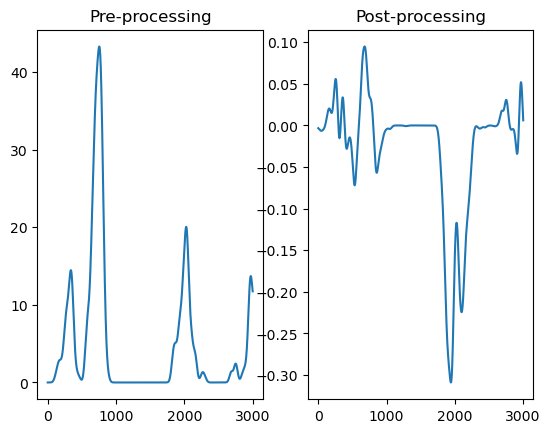

In [4]:
fig,ax = plt.subplots(1,2)
ax[0].plot(data[0,5,:])
ax[1].plot(data_final[:3003,5])
ax[0].set_title('Pre-processing')
ax[1].set_title('Post-processing')

In [5]:
num_components = 8
X = data_final[trainMask,:]
SCA_0 = SCA(torch.tensor(X,dtype=torch.float),num_components)

init recon: 118.9818344116211
init sparse: 11.898183822631836
init orth: 11.898183822631836
lam_sparse: 0.008733981288969517
lam_orth: 21.24675750732422


100%|██████████| 3000/3000 [00:13<00:00, 224.41it/s]


Text(0, 0.5, 'loss')

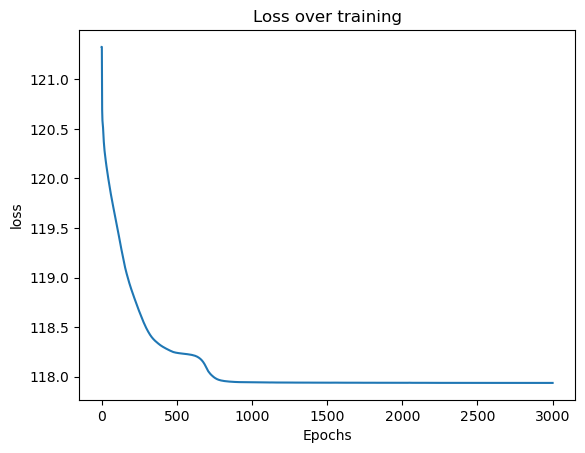

In [6]:
fig,ax = plt.subplots()
ax.plot(SCA_0['losses'].detach().numpy())
ax.set_title('Loss over training')
ax.set_xlabel('Epochs')
ax.set_ylabel('loss')

## Alternatively, fitting data via WPCA

In [10]:
latent_sca = SCA_0['latent'].detach().numpy()
out_sca = SCA_0['out'].detach().numpy()

W_ = create_W(torch.tensor(X)).numpy()
svd = TruncatedSVD(num_components)
svd.fit(W_@X)
U = svd.components_.T
V = svd.components_

latent_wpca = X@U
out_wpca = latent_wpca@V

## Compare $R^2$ of the two approaches

In [14]:
r2_sca = r2_score(X, out_sca, sample_weight=np.diag(W_), multioutput = 'variance_weighted')
r2_wpca = r2_score(X, out_wpca, sample_weight=np.diag(W_), multioutput = 'variance_weighted')

print(f"r2 of SCA: {r2_sca}")
print(f"r2 of WPCA: {r2_wpca}")

r2 of SCA: 0.6754148329205903
r2 of WPCA: 0.6772661859135781


## Reorder by cross-condition variance

In [19]:
rs_sca_latent = np.reshape(latent_sca,(-1,C,num_components),order='F')
sca_var = np.var(rs_sca_latent,axis=1)
max_occ = np.max(sca_var,axis=0)
sca_order = np.argsort(max_occ)
ordered_sca = rs_sca_latent[:,:,sca_order]

rs_wpca_latent = np.reshape(latent_wpca,(-1,C,num_components),order='F')
sca_var = np.var(rs_wpca_latent,axis=1)
max_occ = np.max(sca_var,axis=0)
wpca_order = np.argsort(max_occ)
ordered_sca = rs_wpca_latent[:,:,sca_order]

target_idx = 20
move_idx = 77
return_idx = 200

In [21]:
# range for y axis
yRange = [-1.8,1.8]

fig = make_subplots(rows=R_est,cols = 1,shared_xaxes = True,vertical_spacing = 0)

for ii in range(R_est):

    for jj in range(numConds):
        latTrace = go.Scatter(y = rs_sca_latent[:,jj,ii], line = go.scatter.Line(color = cMap[jj],width = 2.5),showlegend = False)
        fig.add_trace(latTrace,row = ii+1,col=1)

    # mark important task events
    fig.add_vline(x = tgt_idx,row = ii+1,col = 1, line_color = 'black')
    fig.add_vline(x = move_idx,row = ii+1,col = 1, line_color = 'black')
    fig.add_vline(x = ret_idx,row = ii+1,col = 1, line_color = 'black')

    # add a vertical line for scale
    scaleLine = go.Scatter(x = [0,0],y = [-1,1],showlegend = False,mode = 'lines',
                            line = go.scatter.Line(color = 'black',width = 5))
    fig.add_trace(scaleLine,row = ii+1,col = 1)


# clean up
fig.update_layout(height = 2000,width =600,title = 'SCA',title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False,range = yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [0,50],ticktext = ['0','500'],visible = True,row = R_est,col = 1)

fig.show()

NameError: name 'make_subplots' is not defined